# Project: Preprocessing JDM Used Cars Dataset
**Goal**: Membersihkan dan menyiapkan dataset mobil bekas JDM agar siap digunakan untuk prediksi harga menggunakan Machine Learning.
**Timeline**: Day 1 - Day 7

In [1]:
import pandas as pd
import numpy as np

# 1. Load Dataset
df = pd.read_csv('jdm_used_cars.csv')

# 2. Drop kolom 'Unnamed: 0' segera setelah load (Best Practice)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 3. Inspeksi Awal
print(f"Dimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
display(df.head())
df.info()

Dimensi dataset: 2318 baris, 10 kolom


,price,mark,model,year,mileage,engine_capacity,transmission,drive,hand_drive,fuel
0,80,nissan,march,2003,80000,1240,at,2wd,rhd,gasoline
1,110,nissan,march,2010,53000,1200,at,2wd,rhd,gasoline
2,165,nissan,lafesta,2005,47690,2000,at,2wd,rhd,gasoline
3,190,toyota,avensis,2008,130661,1990,at,2wd,rhd,gasoline
4,190,daihatsu,mira,2006,66300,660,at,2wd,rhd,gasoline


<class 'pandas.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   price            2318 non-null   int64
 1   mark             2318 non-null   str  
 2   model            2318 non-null   str  
 3   year             2318 non-null   int64
 4   mileage          2318 non-null   int64
 5   engine_capacity  2318 non-null   int64
 6   transmission     2318 non-null   str  
 7   drive            2318 non-null   str  
 8   hand_drive       2318 non-null   str  
 9   fuel             2318 non-null   str  
dtypes: int64(4), str(6)
memory usage: 181.2 KB


## Day 2 & 3: Profiling & Visualization
Mengecek kualitas data (missing values, duplikat) dan visualisasi sebarannya.

Jumlah duplikat: 0
Tidak ada missing values dalam dataset.


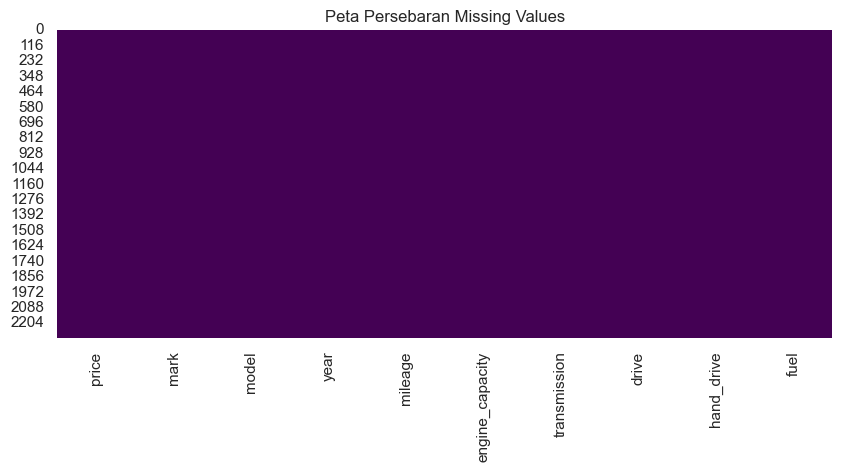

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cek Duplikat
print(f"Jumlah duplikat: {df.duplicated().sum()}")
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()

# Cek Missing Values
missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    display(pd.DataFrame({'Total Missing': missing_data, 'Percentage (%)': (missing_data/len(df))*100}))
else:
    print("Tidak ada missing values dalam dataset.")

# Visualisasi Heatmap Missing Values
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Peta Persebaran Missing Values')
plt.show()

## Day 4: Outlier Detection & Handling
Menggunakan metode IQR (Interquartile Range) untuk membersihkan data ekstrem pada kolom harga dan jarak tempuh.

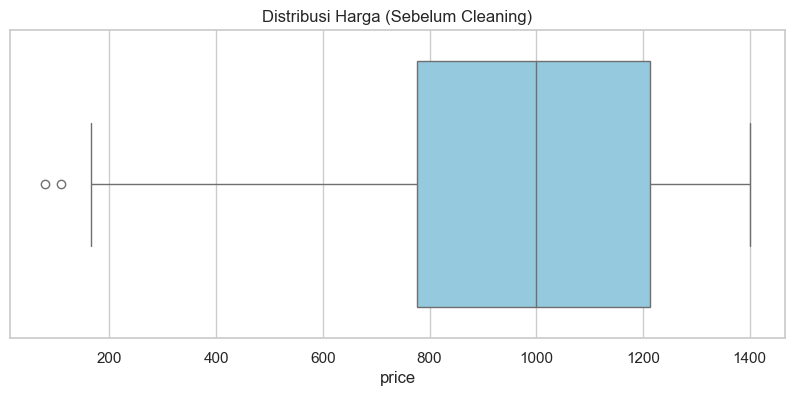

Kolom 'price': Dibuang 2 outlier.
Kolom 'mileage': Dibuang 46 outlier.


In [3]:
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_filtered = dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)]
    print(f"Kolom '{column}': Dibuang {len(dataframe) - len(df_filtered)} outlier.")
    return df_filtered

# Visualisasi sebelum cleaning
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['price'], color='skyblue')
plt.title('Distribusi Harga (Sebelum Cleaning)')
plt.show()

# Eksekusi Cleaning
df = remove_outliers_iqr(df, 'price')
df = remove_outliers_iqr(df, 'mileage')

## Day 5 & 6: Feature Encoding & Scaling
Mengubah data kategori menjadi angka (One-Hot Encoding) dan menyetarakan skala fitur numerik.

In [4]:
from sklearn.preprocessing import StandardScaler

# 1. Drop High Cardinality
if 'model' in df.columns:
    df = df.drop(columns=['model'])

# 2. One-Hot Encoding
kolom_kategori = df.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=kolom_kategori, drop_first=True)

# 3. Scaling
kolom_numerik = ['year', 'mileage', 'engine_capacity']
scaler = StandardScaler()
df_encoded[kolom_numerik] = scaler.fit_transform(df_encoded[kolom_numerik])

display(df_encoded.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_7728\3500542080.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  kolom_kategori = df.select_dtypes(include=['object']).columns.tolist()


,price,year,mileage,engine_capacity,mark_bmw,mark_chrysler,mark_citroen,mark_daihatsu,mark_ford,mark_gm,...,transmission_cvt,transmission_mt,drive_4wd,drive_awd,hand_drive_lhd,hand_drive_rhd,fuel_diesel,fuel_gasoline,fuel_hybrid,fuel_lpg
2,165,-0.260302,-1.182687,0.916686,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
3,190,0.555838,0.846600,0.898281,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
4,190,0.011745,-0.727528,-1.549646,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
5,190,-0.532349,-0.358215,-1.549646,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
6,220,1.099932,0.512482,-0.555751,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False


## Day 7: Export Cleaned Data
Menyimpan dataset final yang siap digunakan untuk training model.

In [5]:
df_encoded.to_csv('jdm_used_cars_cleaned.csv', index=False)
print("File 'jdm_used_cars_cleaned.csv' berhasil disimpan!")

File 'jdm_used_cars_cleaned.csv' berhasil disimpan!
